In [29]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
## Geometric Brownian motion
# S(t) = S0 * exp((mu - 0.5 * sigma^2)*dt + sigma*sqrt(dt) * Z)

In [31]:
# GBM simulator
def simulate_gbm(S0, mu, sigma, T, N):
    dt = T / N                                  # incremental time difference, on which we are calculating the price
    t = np.linspace(0, T, N)                    # time array (X-axis)
    W = np.random.standard_normal(size=N)       # normal distribution between time 0 to time T
    W = np.cumsum(W) * np.sqrt(dt)              # Standard Brownian motion
    X = (mu - 0.5 * sigma**2) * t + sigma * W   
    S = S0 * np.exp(X)
    return S

In [32]:
#defining initial parameters
S0 = 100      # Initial stock price
mu = 0.05     # Drift
sigma = 0.20  # Volatility
T = 1         # Time horizon (years)
N = 252       # Number of days

In [33]:
def PlotSimulatedPaths(paths):
    plt.figure(figsize = (12, 10))
    plt.plot(paths.T)
    plt.title('Geometric Brownian Motion')
    plt.xlabel('no. of trading days or time steps')
    plt.ylabel('Price')

    plt.show()

In [34]:
def RunSimulationEngine(sim_runs):
    paths = np.zeros((sim_runs, N))

    for i in range(sim_runs):
        paths[i] = simulate_gbm(S0, mu, sigma, T, N)
        
    PlotSimulatedPaths(paths)
    
    return paths

In [35]:
def GetTerminalPrices(paths):
    return paths[:, -1]

In [36]:
def PlotTerminalPrices(prices):
    plt.figure(figsize = (10, 6))
    plt.hist(prices)
    plt.title('Terminal prices of GBP Paths')
    plt.xlabel('Price')
    plt.ylabel('Frequency')

    plt.show()

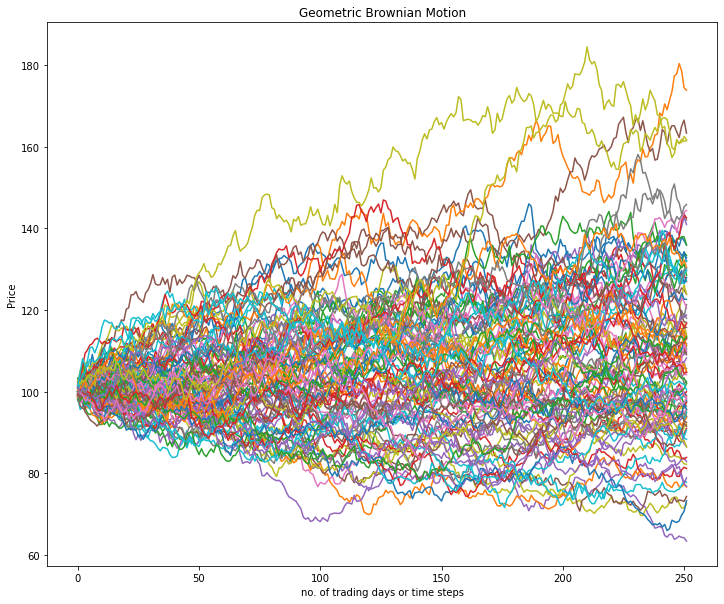

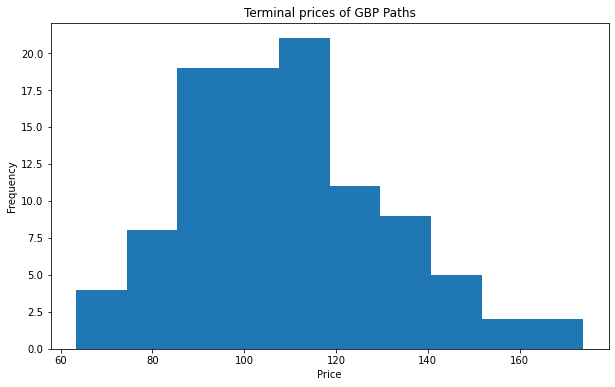

In [37]:
#for 100 simulation runs
simulatedPaths = RunSimulationEngine(100)
terminalPrices = GetTerminalPrices(simulatedPaths)
PlotTerminalPrices(terminalPrices)

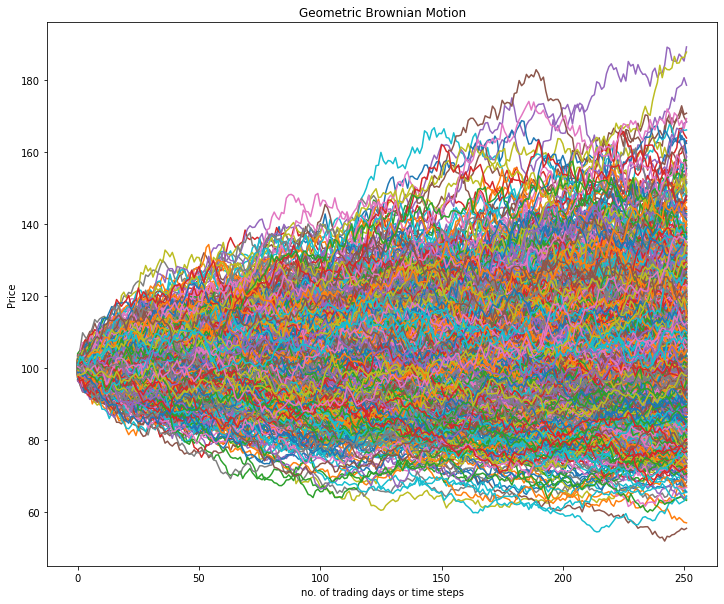

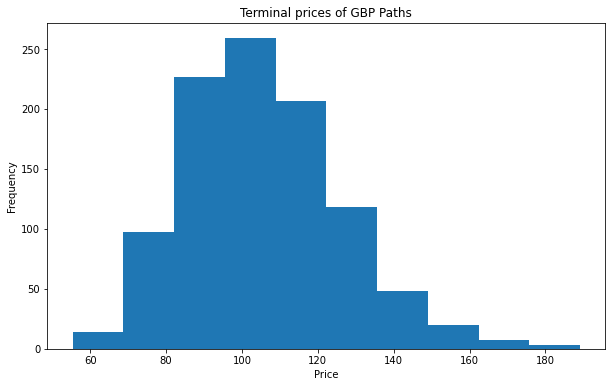

In [38]:
#for 1000 simulation runs
simulatedPaths = RunSimulationEngine(1000)
terminalPrices = GetTerminalPrices(simulatedPaths)
PlotTerminalPrices(terminalPrices)

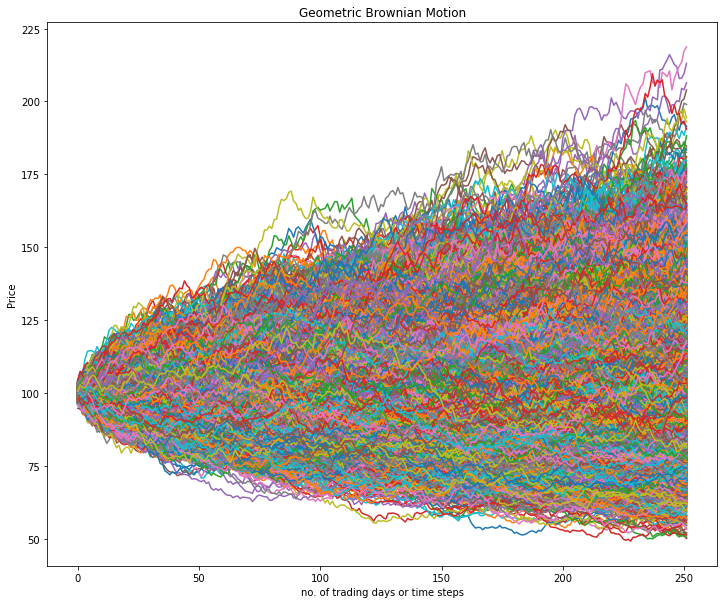

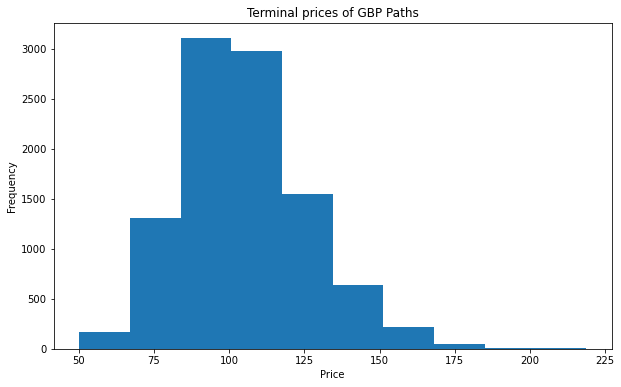

In [39]:
#for 10000 simulation runs
simulatedPaths = RunSimulationEngine(10000)
terminalPrices = GetTerminalPrices(simulatedPaths)
PlotTerminalPrices(terminalPrices)